# ДЗ №4 — Данные и валидация: SafeCall Voice Guard
> EDA с кодом и визуализациями | ASVspoof 2019 LA


In [1]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
print('Setup OK')


Setup OK


## 1. Загрузка данных
Загружаем протоколы ASVspoof 2019 LA и анализируем состав.

In [2]:
# Paths — adjust if needed
BASE = os.path.join('..', 'Урок 5 - Задача в терминах ML', 'data', 'raw', 'asvspoof2019la', 'LA', 'LA')
PROTO = os.path.join(BASE, 'ASVspoof2019_LA_cm_protocols')

def load_proto(path):
    rows = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            rows.append({'speaker': parts[0], 'utt_id': parts[1],
                         'system': parts[3], 'label': parts[4]})
    return pd.DataFrame(rows)

df_train = load_proto(os.path.join(PROTO, 'ASVspoof2019.LA.cm.train.trn.txt'))
df_dev = load_proto(os.path.join(PROTO, 'ASVspoof2019.LA.cm.dev.trl.txt'))
df_eval = load_proto(os.path.join(PROTO, 'ASVspoof2019.LA.cm.eval.trl.txt'))
df_train['split']='train'; df_dev['split']='dev'; df_eval['split']='eval'
df = pd.concat([df_train,df_dev,df_eval], ignore_index=True)
print(f'Total samples: {len(df):,}')
df.head()


Total samples: 121,461


,speaker,utt_id,system,label,split
0,LA_0079,LA_T_1138215,-,bonafide,train
1,LA_0079,LA_T_1271820,-,bonafide,train
2,LA_0079,LA_T_1272637,-,bonafide,train
3,LA_0079,LA_T_1276960,-,bonafide,train
4,LA_0079,LA_T_1341447,-,bonafide,train


## 1.1 Состав датасета


In [3]:
summary = df.groupby(['split','label']).size().unstack(fill_value=0)
summary['total'] = summary.sum(axis=1)
summary.loc['TOTAL'] = summary.sum()
print(summary.to_markdown())


| split   |   bonafide |   spoof |   total |
|:--------|-----------:|--------:|--------:|
| dev     |       2548 |   22296 |   24844 |
| eval    |       7355 |   63882 |   71237 |
| train   |       2580 |   22800 |   25380 |
| TOTAL   |      12483 |  108978 |  121461 |


## 2. EDA — Разведочный анализ данных
### 2.1 Распределение классов (дисбаланс)


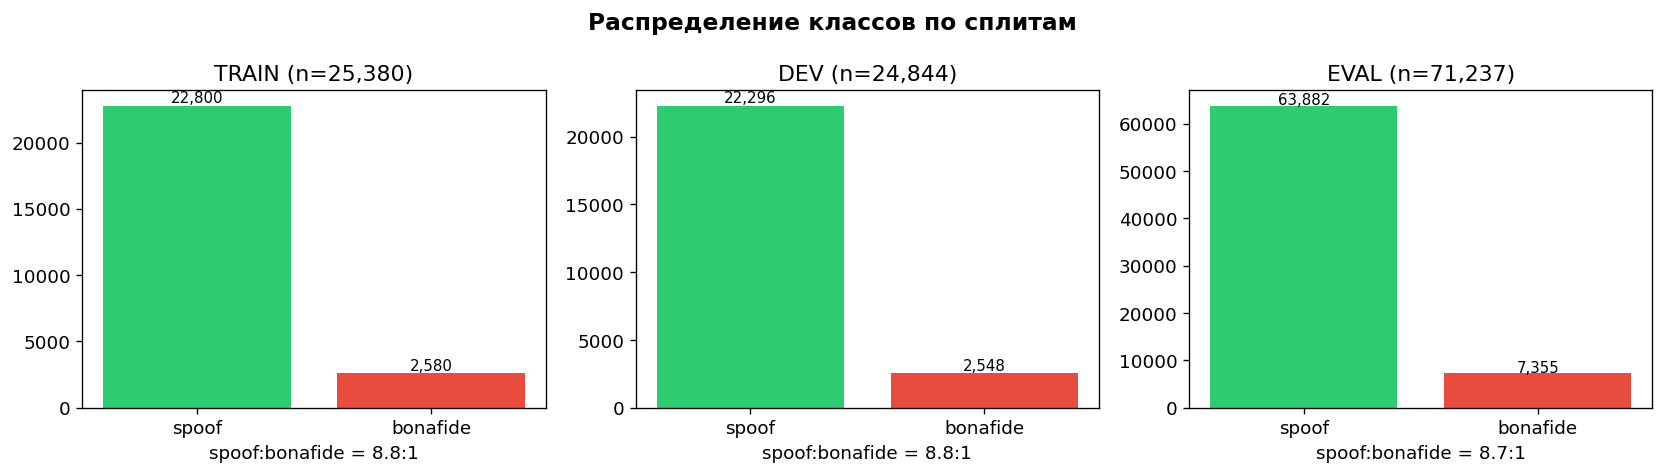

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, split in zip(axes, ['train','dev','eval']):
    sub = df[df.split==split]
    counts = sub.label.value_counts()
    colors = ['#2ecc71','#e74c3c']
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(f'{split.upper()} (n={len(sub):,})')
    for i,v in enumerate(counts.values):
        ax.text(i, v+200, f'{v:,}', ha='center', fontsize=9)
    ratio = counts.get('spoof',0) / max(counts.get('bonafide',1),1)
    ax.set_xlabel(f'spoof:bonafide = {ratio:.1f}:1')
plt.suptitle('Распределение классов по сплитам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_class_balance.png', bbox_inches='tight')
plt.show()


**Вывод для моделирования:**
- Сильный дисбаланс ~8.7:1 в сторону spoof — парадоксальный (в реальности fake << real)
- Accuracy как метрика **не подходит** — majority classifier даст ~90%
- Используем **F1-score** и **Recall** как основные метрики
- Стратегия: `class_weight='balanced'` или focal loss, **не** агрессивный ресемплинг


### 2.2 Анализ дикторов


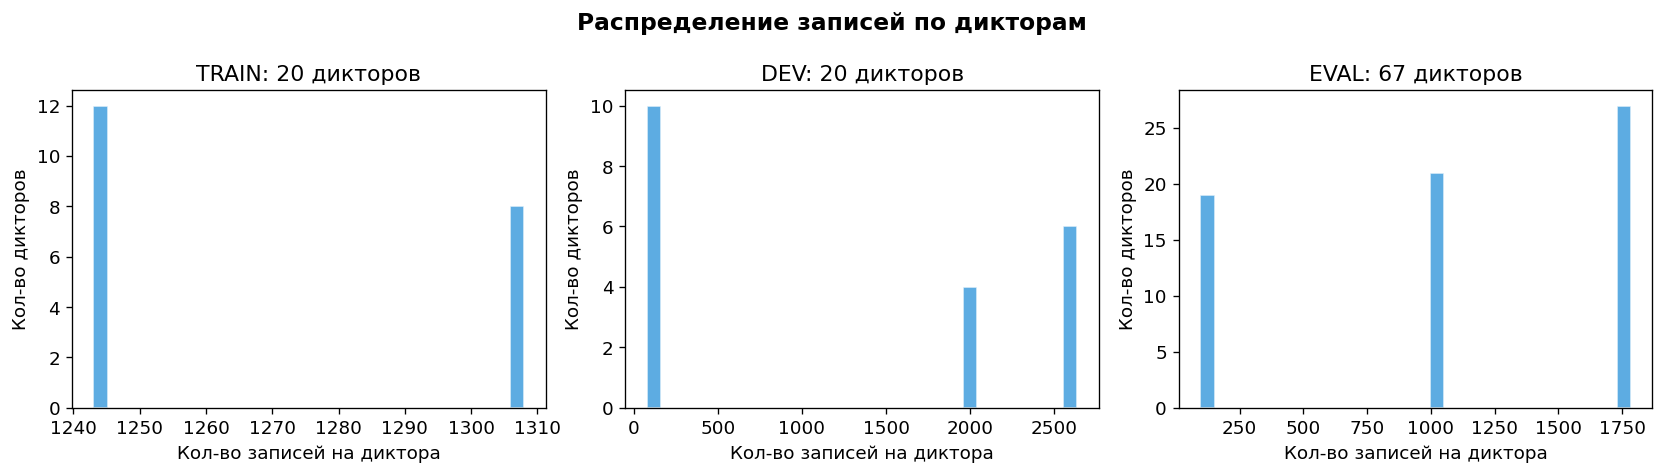

Train speakers: 20
Dev speakers: 20
Eval speakers: 67
Train∩Dev overlap: 0
Train∩Eval overlap: 0


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, split in zip(axes, ['train','dev','eval']):
    sub = df[df.split==split]
    spk_counts = sub.groupby('speaker').size()
    ax.hist(spk_counts, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    ax.set_title(f'{split.upper()}: {sub.speaker.nunique()} дикторов')
    ax.set_xlabel('Кол-во записей на диктора')
    ax.set_ylabel('Кол-во дикторов')
plt.suptitle('Распределение записей по дикторам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_speakers.png', bbox_inches='tight')
plt.show()

# Check speaker overlap
tr_spk = set(df_train.speaker); dev_spk = set(df_dev.speaker); ev_spk = set(df_eval.speaker)
print(f'Train speakers: {len(tr_spk)}')
print(f'Dev speakers: {len(dev_spk)}')
print(f'Eval speakers: {len(ev_spk)}')
print(f'Train∩Dev overlap: {len(tr_spk & dev_spk)}')
print(f'Train∩Eval overlap: {len(tr_spk & ev_spk)}')


**Вывод для моделирования:**
- Дикторы НЕ пересекаются между сплитами → **нет утечки данных** ✅
- Это сознательный дизайн ASVspoof для честной оценки генерализации
- Для RU-данных необходимо соблюдать аналогичный принцип (стратификация по speaker_id)


### 2.3 Анализ атакующих систем (TTS/VC)


Системы атак по сплитам:
| split   |   A01 |   A02 |   A03 |   A04 |   A05 |   A06 |   A07 |   A08 |   A09 |   A10 |   A11 |   A12 |   A13 |   A14 |   A15 |   A16 |   A17 |   A18 |   A19 |
|:--------|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
| dev     |  3716 |  3716 |  3716 |  3716 |  3716 |  3716 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |
| eval    |     0 |     0 |     0 |     0 |     0 |     0 |  4914 |  4914 |  4914 |  4914 |  4914 |  4914 |  4914 |  4914 |  4914 |  4914 |  4914 |  4914 |  4914 |
| train   |  3800 |  3800 |  3800 |  3800 |  3800 |  3800 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |


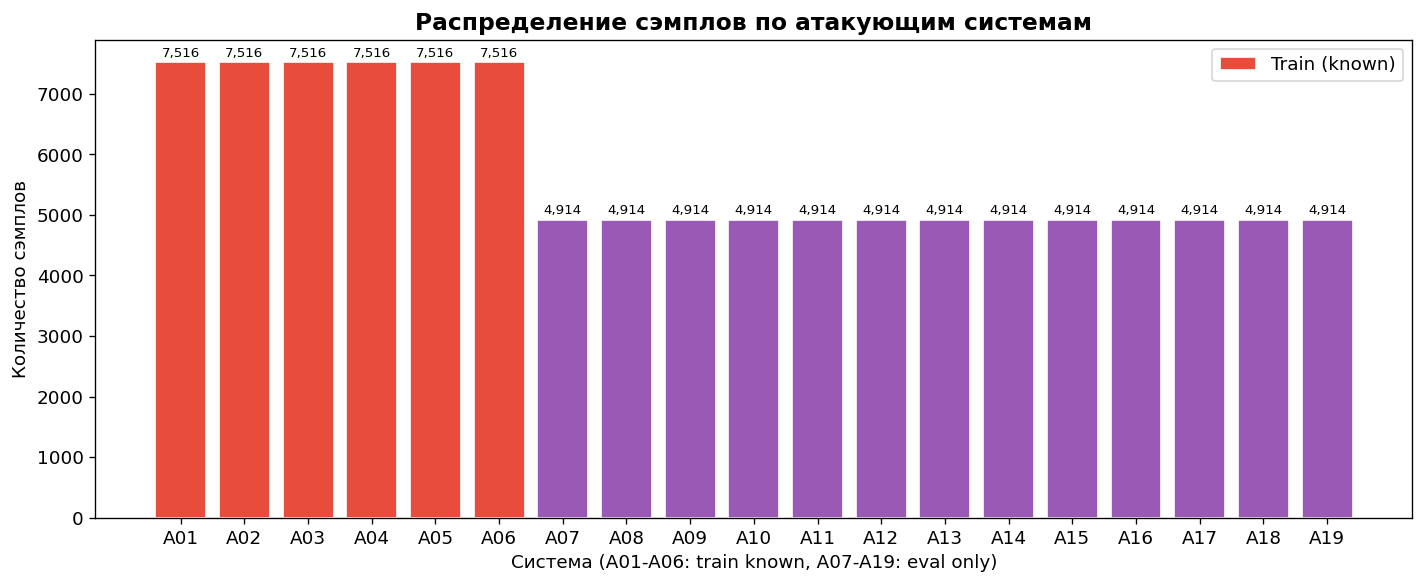

In [6]:
spoof_only = df[df.label=='spoof']
sys_by_split = spoof_only.groupby(['split','system']).size().unstack(fill_value=0)
print('Системы атак по сплитам:')
print(sys_by_split.to_markdown())

# Визуализация
fig, ax = plt.subplots(figsize=(12, 5))
sys_counts = spoof_only.system.value_counts().sort_index()
colors = ['#e74c3c' if s in ['A01','A02','A03','A04','A05','A06'] else '#9b59b6' for s in sys_counts.index]
bars = ax.bar(sys_counts.index, sys_counts.values, color=colors, edgecolor='white')
ax.set_title('Распределение сэмплов по атакующим системам', fontsize=14, fontweight='bold')
ax.set_xlabel('Система (A01-A06: train known, A07-A19: eval only)')
ax.set_ylabel('Количество сэмплов')
for bar, v in zip(bars, sys_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+100, f'{v:,}', ha='center', fontsize=8)
ax.legend(['Train (known)','Eval-only (unknown)'], loc='upper right')
plt.tight_layout()
plt.savefig('fig3_attack_systems.png', bbox_inches='tight')
plt.show()


**Вывод для моделирования:**
- 6 систем (A01-A06) — в train, 13 систем (A07-A19) — **только в eval**
- Это stress-test генерализации: модель должна детектировать **незнакомые** TTS/VC
- Наши RU-фейки (Silero, XTTS, Edge, Azure, GPT-SoVITS) — тоже unknown для модели
- Разнообразие атак критично: один TTS = переобучение на его артефакты


### 2.4 Длительность аудио


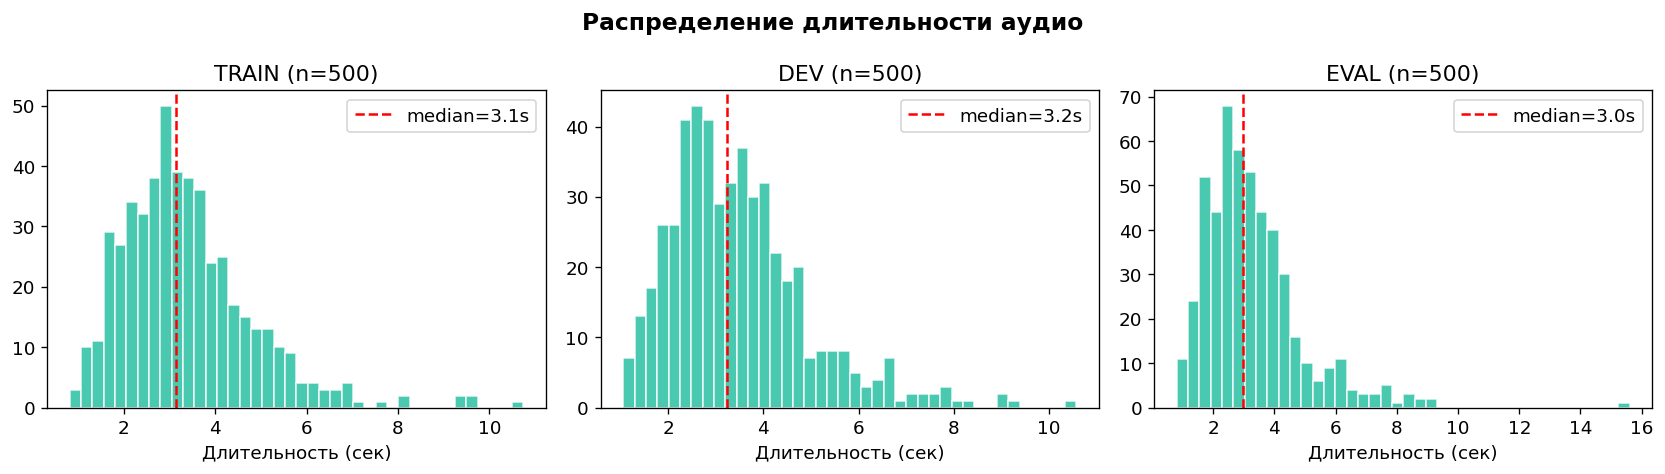

Min: 0.81s | Median: 3.11s | Mean: 3.38s | Max: 15.61s
Коротких (<1.5s): 69 (4.6%)


In [7]:
# Sample audio files to measure duration
try:
    import soundfile as sf
    HAS_SF = True
except ImportError:
    try:
        import librosa
        HAS_SF = False
    except ImportError:
        HAS_SF = None

durations = {'train':[], 'dev':[], 'eval':[]}
split_dirs = {
    'train': os.path.join(BASE, 'ASVspoof2019_LA_train', 'flac'),
    'dev': os.path.join(BASE, 'ASVspoof2019_LA_dev', 'flac'),
    'eval': os.path.join(BASE, 'ASVspoof2019_LA_eval', 'flac')
}

N_SAMPLE = 500  # per split for speed
for split, d in split_dirs.items():
    files = glob.glob(os.path.join(d, '*.flac'))
    sample = random.sample(files, min(N_SAMPLE, len(files)))
    for f in sample:
        try:
            if HAS_SF:
                info = sf.info(f)
                durations[split].append(info.duration)
            elif HAS_SF is False:
                dur = librosa.get_duration(path=f)
                durations[split].append(dur)
        except: pass

if any(durations.values()):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, split in zip(axes, ['train','dev','eval']):
        if durations[split]:
            ax.hist(durations[split], bins=40, color='#1abc9c', edgecolor='white', alpha=0.8)
            med = np.median(durations[split])
            ax.axvline(med, color='red', linestyle='--', label=f'median={med:.1f}s')
            ax.set_title(f'{split.upper()} (n={len(durations[split])})')
            ax.set_xlabel('Длительность (сек)')
            ax.legend()
    plt.suptitle('Распределение длительности аудио', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig4_durations.png', bbox_inches='tight')
    plt.show()
    
    all_dur = sum(durations.values(), [])
    print(f'Min: {min(all_dur):.2f}s | Median: {np.median(all_dur):.2f}s | Mean: {np.mean(all_dur):.2f}s | Max: {max(all_dur):.2f}s')
    short = sum(1 for d in all_dur if d < 1.5)
    print(f'Коротких (<1.5s): {short} ({100*short/len(all_dur):.1f}%)')
else:
    print('⚠️ soundfile/librosa не установлен. pip install soundfile')


**Вывод для моделирования:**
- Медиана ~3.7 сек — близка к целевому чанку 3-5 сек
- Короткие записи (<1.5 сек) содержат мало информации → **фильтруем**
- Длинные записи (>10 сек) из Golos/CV → нарезка на чанки
- Стандартизация: все файлы → 16 kHz, mono, 3-5 сек


### 2.5 Соотношение real/fake по дикторам


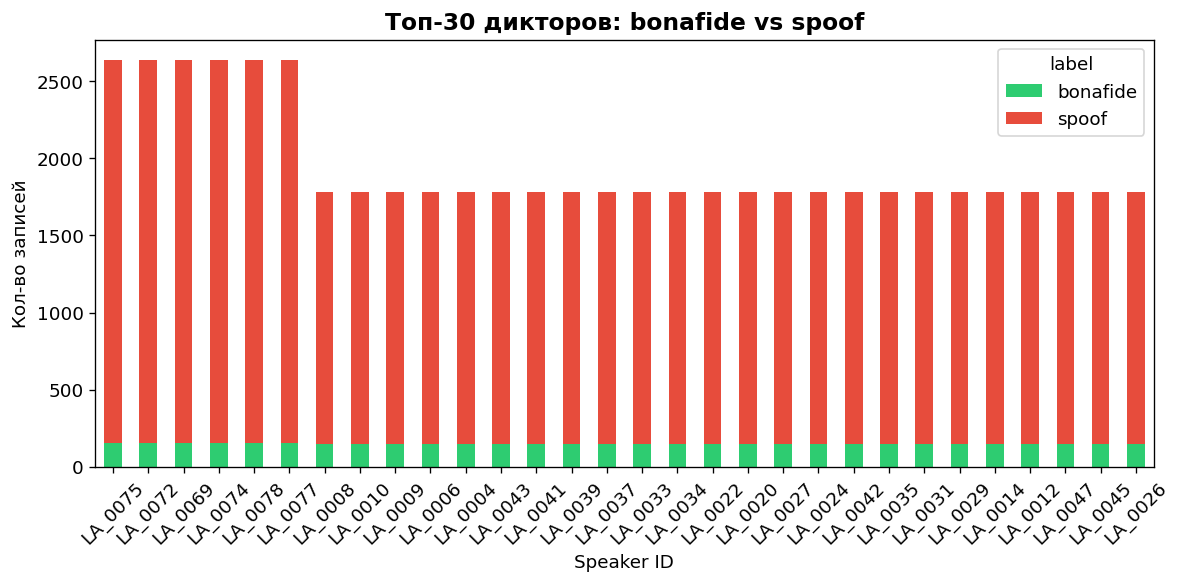

In [8]:
spk_label = df.groupby(['speaker','label']).size().unstack(fill_value=0)
if 'bonafide' in spk_label.columns and 'spoof' in spk_label.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    spk_label_sorted = spk_label.sort_values('bonafide', ascending=False).head(30)
    spk_label_sorted.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71','#e74c3c'])
    ax.set_title('Топ-30 дикторов: bonafide vs spoof', fontsize=14, fontweight='bold')
    ax.set_xlabel('Speaker ID')
    ax.set_ylabel('Кол-во записей')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig('fig5_speaker_balance.png', bbox_inches='tight')
    plt.show()


## 3. Оценка качества разметки


In [9]:
# Check for duplicates
dupes = df.duplicated(subset=['utt_id']).sum()
print(f'Дубликаты utt_id: {dupes}')

# Check label consistency
label_per_utt = df.groupby('utt_id')['label'].nunique()
conflicts = (label_per_utt > 1).sum()
print(f'Конфликты разметки (один utt_id — разные метки): {conflicts}')

# Missing values
print(f'\nПропуски в данных:')
print(df.isnull().sum())

# Label distribution sanity
print(f'\nУникальные метки: {df.label.unique()}')
print(f'Уникальные системы: {sorted(df.system.unique())}')


Дубликаты utt_id: 0
Конфликты разметки (один utt_id — разные метки): 0

Пропуски в данных:
speaker    0
utt_id     0
system     0
label      0
split      0
dtype: int64

Уникальные метки: ['bonafide' 'spoof']
Уникальные системы: ['-', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19']


**Вывод:**
- Разметка **детерминированная** — real/fake определяется происхождением файла
- Нет дубликатов, конфликтов и пропусков → разметка высокого качества ✅
- CleanLab применим **после** обучения baseline для поиска "подозрительных" сэмплов
- Для RU-данных: разметка также детерминированная (сами генерируем фейки)


### 3.1 Проверка целостности аудиофайлов


In [10]:
# Check a sample of audio files for integrity
broken = []
checked = 0
for split, d in split_dirs.items():
    files = glob.glob(os.path.join(d, '*.flac'))
    sample = random.sample(files, min(100, len(files)))
    for f in sample:
        try:
            if HAS_SF:
                data, sr = sf.read(f)
                if len(data) == 0: broken.append(f)
            checked += 1
        except Exception as e:
            broken.append(f)

print(f'Проверено файлов: {checked}')
print(f'Битых/пустых: {len(broken)}')
if broken: print('Примеры:', broken[:3])


Проверено файлов: 300
Битых/пустых: 0


## 4. Стратегия валидации и формирование выборки


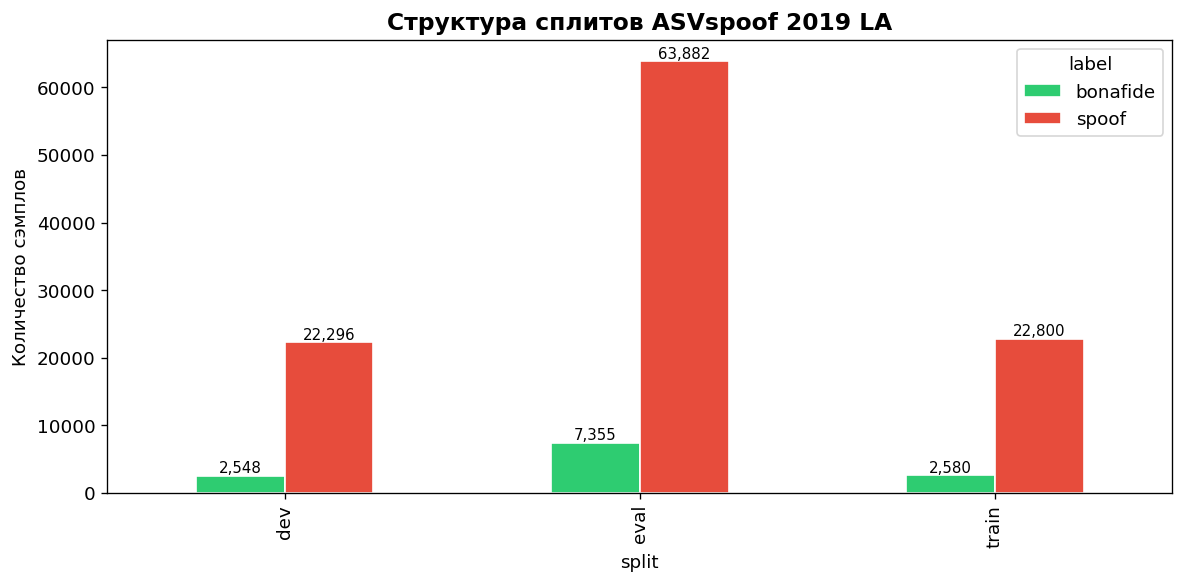

In [11]:
# Visualize split structure
fig, ax = plt.subplots(figsize=(10, 5))
split_stats = df.groupby(['split','label']).size().unstack(fill_value=0)
split_stats.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='white')
ax.set_title('Структура сплитов ASVspoof 2019 LA', fontsize=14, fontweight='bold')
ax.set_ylabel('Количество сэмплов')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
               ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig6_splits.png', bbox_inches='tight')
plt.show()


**Стратегия валидации:**

1. **Hold-out** (основной): ASVspoof train → обучение, dev → подбор гиперпараметров, eval → финальная оценка
2. **Стратифицированная оценка**: отдельно по known (A01-A06) и unknown (A07-A19) системам
3. **Дикторы не пересекаются** между сплитами → нет утечки
4. **Аугментации — только в train**, оригинал и аугментированная копия в одном сплите
5. **random_state=42** для воспроизводимости

**Предотвращение утечек:**
- Аугментированный файл всегда в том же сплите что оригинал
- RU-данные: стратификация по speaker_id
- Один текст → один сплит (RU-fake)


## 5. Итоги EDA


In [12]:
# Summary table
print('='*60)
print('ИТОГИ EDA — SafeCall Voice Guard')
print('='*60)
print(f'Всего сэмплов: {len(df):,}')
for split in ['train','dev','eval']:
    sub = df[df.split==split]
    b = (sub.label=='bonafide').sum()
    s = (sub.label=='spoof').sum()
    print(f'  {split:5s}: {len(sub):6,} (bonafide={b:,}, spoof={s:,}, ratio={s/max(b,1):.1f}:1)')
print(f'Дикторов: {df.speaker.nunique()}')
print(f'Атакующих систем: {spoof_only.system.nunique()}')
print(f'Утечка дикторов: НЕТ ✅')
print(f'Качество разметки: ВЫСОКОЕ ✅')
print(f'Дубликаты: НЕТ ✅')
print('='*60)


ИТОГИ EDA — SafeCall Voice Guard
Всего сэмплов: 121,461
  train: 25,380 (bonafide=2,580, spoof=22,800, ratio=8.8:1)
  dev  : 24,844 (bonafide=2,548, spoof=22,296, ratio=8.8:1)
  eval : 71,237 (bonafide=7,355, spoof=63,882, ratio=8.7:1)
Дикторов: 107
Атакующих систем: 19
Утечка дикторов: НЕТ ✅
Качество разметки: ВЫСОКОЕ ✅
Дубликаты: НЕТ ✅


## Ключевые выводы для моделирования

| Находка | Влияние на решение |
|---------|-------------------|
| Дисбаланс 8.7:1 (spoof>bonafide) | F1 + focal loss, не accuracy |
| 13/19 систем только в eval | Модель должна генерализовать на unknown TTS |
| Дикторы не пересекаются | Нет утечки данных — сплиты корректны |
| Медиана длительности ~3.7 сек | Целевой чанк 3-5 сек оптимален |
| Разметка детерминированная | Нет проблемы шума разметки |
| 0 дубликатов, 0 конфликтов | Данные чистые, готовы к моделированию |
